# CSIS3290 Term Project

**Student Name:** Leo Nguyen

**Student ID:** 300413224

### Problem Overview

https://data.world/sonalnew/credit-card-customers
The objective of this project is to predict whether a bank customer is likely to churn based on behavioral and financial features

## 1. Data Loading and inspection

In [60]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [61]:
#insert raw data
file_path = "Dataset/BankChurners.csv"
df_raw = pd.read_csv(file_path)
df_raw.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [62]:
print(df_raw['Attrition_Flag'].value_counts()) #check the questions to choose the target col

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


In [63]:
df_raw.shape

(10127, 23)

In [64]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [65]:
df_raw.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


## 2. Data Wrangling and transformation

In [66]:
print(df_raw.isna().sum().sort_values(ascending=False))
print("Duplicate rows:", df_raw.duplicated().sum())

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [67]:
#Drop useless columns. These columns have no predictive meaning.
df = df_raw.drop(columns=['CLIENTNUM',
                          'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                          'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
                         ])
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [68]:
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer':0,
    'Attrited Customer': 1
})

In [69]:
df.columns = [col.strip().replace(" ", "_") for col in df.columns]
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [70]:
df.to_csv("Dataset/bank_churn_cleaned.csv", index=False)

## 3. EDA

**3.1 Target Distribution**

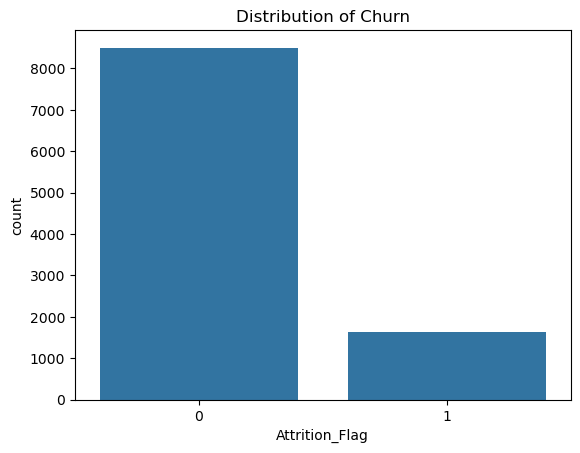

In [71]:
#How target distribute?
sns.countplot(x='Attrition_Flag', data=df)
plt.title("Distribution of Churn")
plt.savefig("Report/images/Distribution_Churn.png", dpi=300)

plt.show()
#0 means existing #1 is churn

### Observation
The dataset is moderately imbalanced, with many more existing customer than attrited customer. This suggests that recall for the minority class should be monitored carefully.

**3.2 Numerical features vs target**

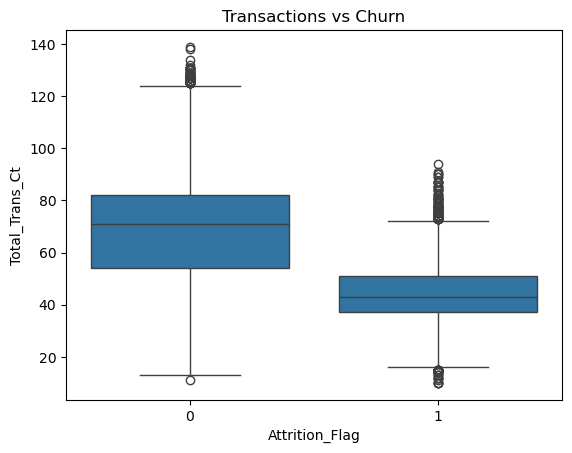

In [72]:
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Ct', data=df)
plt.title("Transactions vs Churn")
plt.savefig("Report/images/Transaction_Churn.png", dpi=300)

plt.show()

Customers who churn tend to have lower transaction counts, indicating reduced engagement.

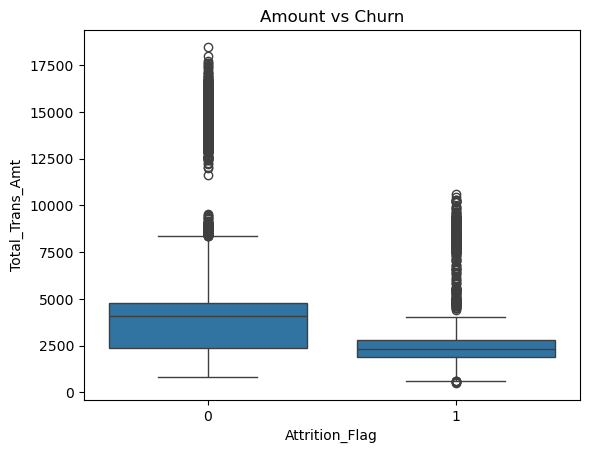

In [73]:
#Check whether they spend money less or not
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Amt', data=df)
plt.title("Amount vs Churn")
plt.savefig("Report/images/Amount_Churn.png", dpi=300)

plt.show()

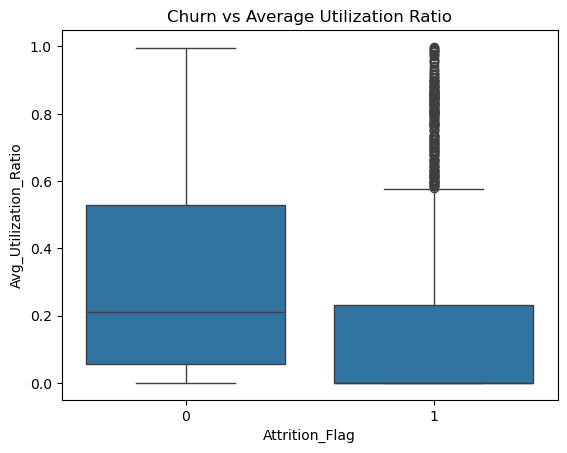

In [74]:
sns.boxplot(x='Attrition_Flag', y='Avg_Utilization_Ratio', data=df)
plt.title("Churn vs Average Utilization Ratio")
plt.savefig("Report/images/Ratio_Churn.png", dpi=300)

plt.show()

### Observation
Attrited customers tend to have lower transaction counts and lower transaction amounts, suggesting lower engagement.

**3.3 Categorical features vs target**

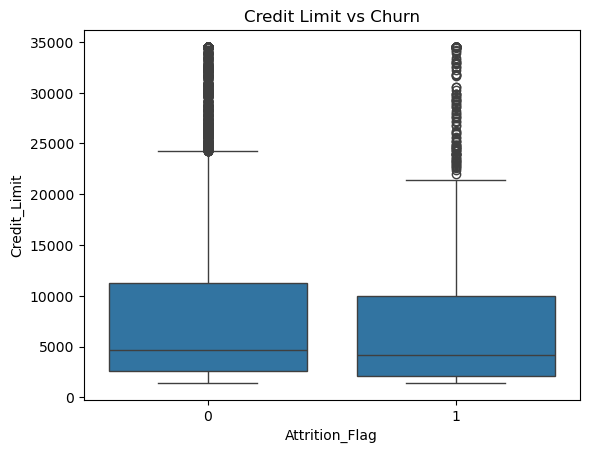

In [75]:
sns.boxplot(x='Attrition_Flag', y='Credit_Limit', data=df)
plt.title("Credit Limit vs Churn")
plt.savefig("Report/images/Creditlimit_Churn.png", dpi=300)

plt.show()

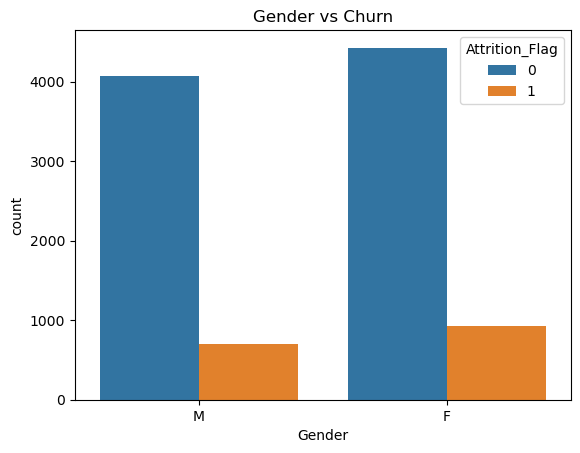

In [76]:
#Check whether feature impacts to churn or not
sns.countplot(x='Gender', hue='Attrition_Flag', data=df)
plt.title("Gender vs Churn")
plt.savefig("Report/images/Gender_Churn.png", dpi=300)

plt.show()

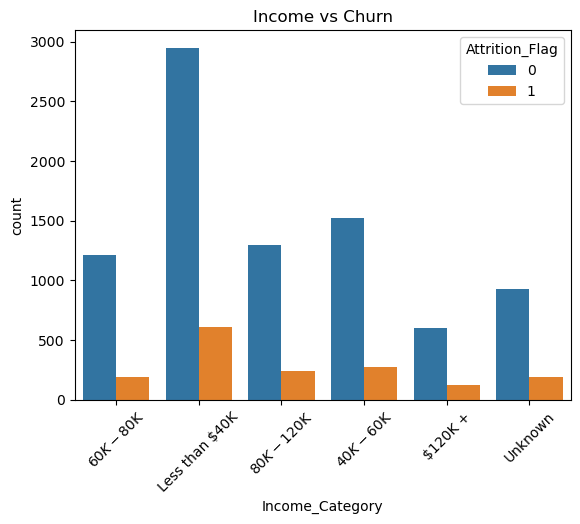

In [77]:
sns.countplot(x='Income_Category', hue='Attrition_Flag', data=df)
plt.title("Income vs Churn")
plt.xticks(rotation=45)
plt.savefig("Report/images/Income_Churn.png", dpi=300)

plt.show()

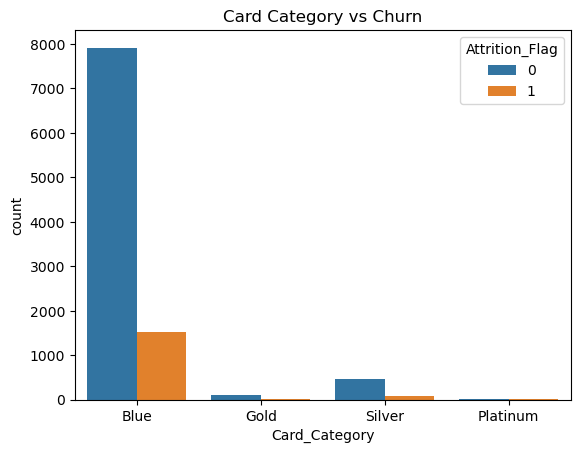

In [78]:
sns.countplot(x='Card_Category', hue='Attrition_Flag', data=df)
plt.title("Card Category vs Churn")
plt.savefig("Report/images/Card_Churn.png", dpi=300)
plt.show()

### Observation
Attrition may vary across customer groups such as income category and card category. These features may contribute useful information to the classification model.

Text(0.5, 1.0, 'Correlation Matrix')

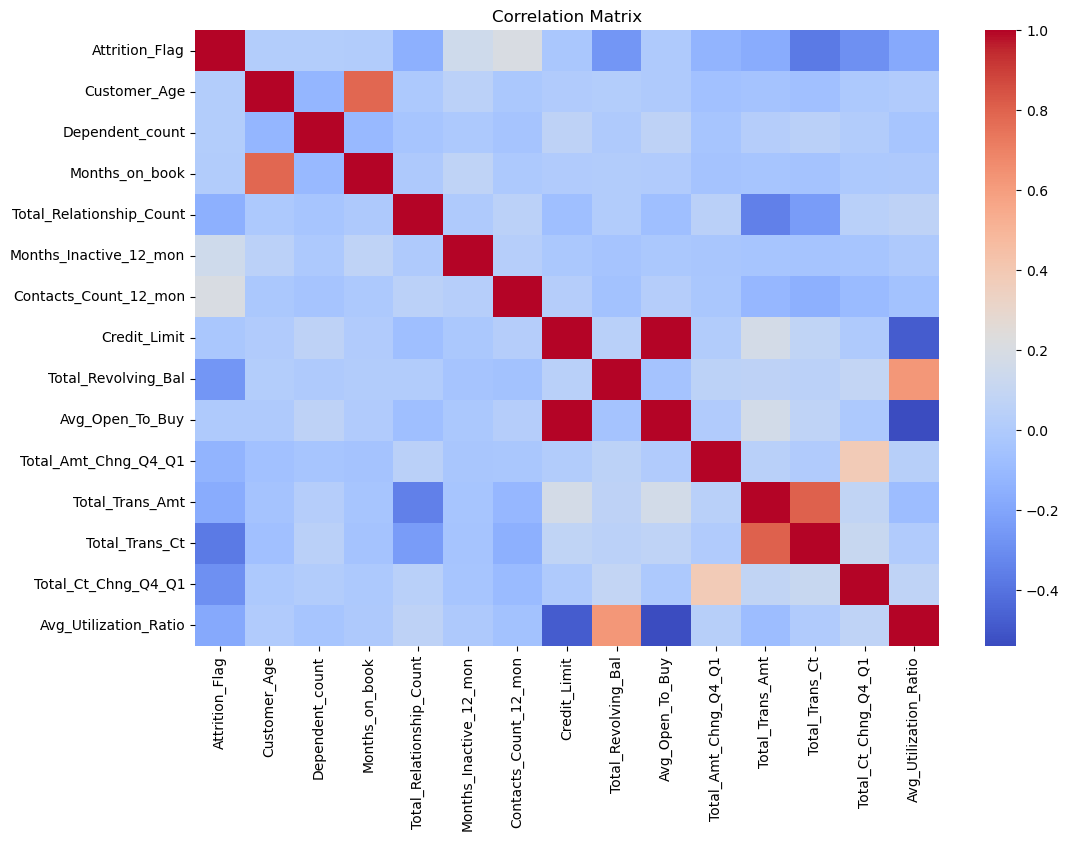

In [79]:
#Correlation map (choose numeric columns)
df_numeric = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(12,8))
sns.heatmap(df_numeric.corr(), cmap='coolwarm')
plt.savefig("Report/images/Correlation_Matrix.png", dpi=300)
plt.title("Correlation Matrix")

In the table, we can see customers who churn tend to have lower transaction counts and lower utilization ratios, indicating reduced engagement with banking services.

Correlation analysis reveals that customer activity metrics, such as transaction count and transaction amount, are associated with churn behavior.

## 4. Feature Engineering

In [80]:
#We will drop Avg_Open_To_Buy based on redundancy and improve model interpretability
df = df.drop(columns=['Avg_Open_To_Buy'], errors="ignore")

In [81]:
df["Avg_Trans_Value"] = df["Total_Trans_Amt"] / df["Total_Trans_Ct"]
df["Avg_Trans_Value"] = df["Avg_Trans_Value"].replace([np.inf,-np.inf], np.nan)

In [82]:
df["Avg_Trans_Value"].isna().sum()

np.int64(0)

### Observation
Average transaction value may captuire a customer's spending pattern better than raw transaction count or total amount alone

In [83]:
X= df.drop("Attrition_Flag", axis=1)
y = df["Attrition_Flag"]

In [84]:
numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric featurees:", numeric_features)
print("Categorical features:", categorical_features)

Numeric featurees: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Avg_Trans_Value']
Categorical features: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


## 5. Train/Test Split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Avg_Trans_Value']
Categorical features: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [87]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                          ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
                
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [88]:
names = ["Logistic Regression", "Random Forest", "XGBoost", "KNN","SVC"]
classifiers = [
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight="balanced"),
    XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    ),
    KNeighborsClassifier(n_neighbors=5),
    SVC(kernel ="rbf", probability = True, random_state=42)
]

results = []
best_score = -1
best_pipe = None
best_name = None

In [89]:
for name, clf in zip(names, classifiers):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    if f1 > best_score:
        best_score = f1
        best_pipe = pipe
        best_name = name
        best_y_pred = y_pred
        best_y_prob = y_prob

results_df = pd.DataFrame(
    results,
    columns=["Classifier", "Accuracy", "Precision", "Recall", "F1"]
)

display(results_df.sort_values(by="F1", ascending=False))
print("Best model:", best_name)
print("Best F1:", round(best_score, 4))

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

,Classifier,Accuracy,Precision,Recall,F1
2,XGBoost,0.973840,0.956376,0.876923,0.914928
4,SVC,0.943731,0.913725,0.716923,0.803448
1,Random Forest,0.904738,0.650000,0.880000,0.747712
3,KNN,0.920039,0.852814,0.606154,0.708633
0,Logistic Regression,0.869694,0.563410,0.833846,0.672457


Best model: XGBoost
Best F1: 0.9149


Recall is important in this problem because failing to identify customers who would like to churn can result in lost revenue. Howerver, to balance false positive and false negative between recall and precision so the f1-score was used as the primary evaluation metric.

In [90]:
def evaluate_model(name, y_test, y_pred, y_prob=None):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"========={name}=========")
    print("Accuracy :", round(acc,4))
    print("Precision :", round(prec,4))
    print("Recall :", round(rec, 4))
    print("F1-score :",round(f1,4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.savefig("Report/images/Confusion_Matrix.png", dpi=300)
    plt.show()

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f"{name} AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.savefig("Report/images/ROC_Curve.png", dpi=300)

        plt.legend()
        plt.show()

=========XGBoost=========
Accuracy : 0.9738
Precision : 0.9564
Recall : 0.8769
F1-score : 0.9149

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1701
           1       0.96      0.88      0.91       325

    accuracy                           0.97      2026
   macro avg       0.97      0.93      0.95      2026
weighted avg       0.97      0.97      0.97      2026



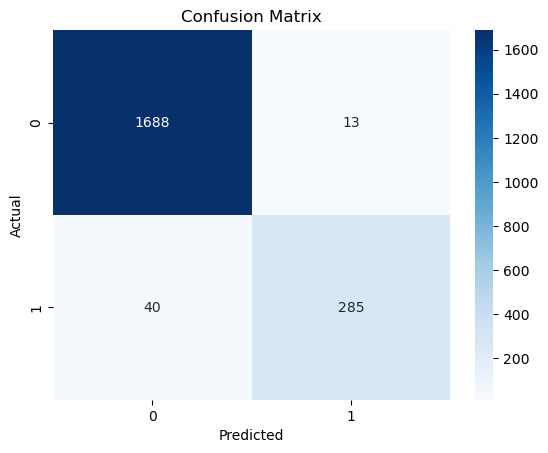

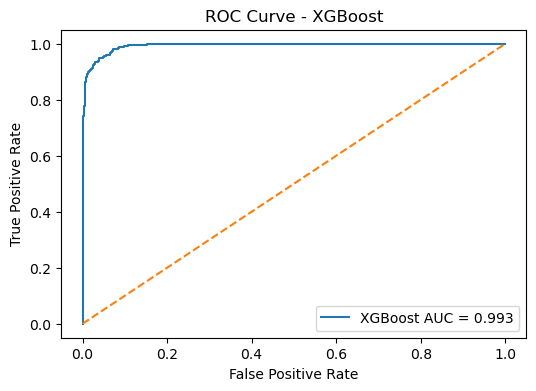

In [91]:
evaluate_model(best_name, y_test, best_y_pred, best_y_prob)

Overall the model achieved strong overall performance with an accuracy of an 97%, indication a good balance precision and recall For the non-churn class, the model performed exceptionally well with a recall of 99%, correctly identifying of existing customers. For the churn class, the model achieved a precision of 96% and a recall of 88%, meaning that while most churn case were correctly identify The confusion matrix shows that the number of false positives is very low ( 13 cases), indicating efficient targeting of churn prediction. However, there are 40 false negatives, which represent missed opportunities for continued customer.

## 6.Out of sample prediction

In [92]:
new_customers = pd.DataFrame([
    {
        "Customer_Age": 45,
        "Gender":"F",
        "Dependent_count": 2,
        "Education_Level":"Graduate",
        "Marital_Status":"Married",
        "Income_Category":"$40K-$60K",
        "Card_Category":"Blue",
        "Months_on_book": 36,
        "Total_Relationship_Count": 4,
        "Months_Inactive_12_mon": 3,
        "Contacts_Count_12_mon": 4,
        "Credit_Limit": 6000,
        "Total_Revolving_Bal": 900,
        "Total_Amt_Chng_Q4_Q1": 0.8,
        "Total_Trans_Amt": 1800,
        "Total_Trans_Ct": 35,
        "Total_Ct_Chng_Q4_Q1": 0.7,
        "Avg_Utilization_Ratio": 0.22,
        "Avg_Trans_Value": 1800/35
    },
    {
        "Customer_Age": 51,
        "Gender":"M",
        "Dependent_count": 3,
        "Education_Level":"Graduate",
        "Marital_Status":"Single",
        "Income_Category":"Less than $40K",
        "Card_Category":"Blue",
        "Months_on_book": 45,
        "Total_Relationship_Count": 2,
        "Months_Inactive_12_mon": 2,
        "Contacts_Count_12_mon": 5,
        "Credit_Limit": 3000,
        "Total_Revolving_Bal": 0,
        "Total_Amt_Chng_Q4_Q1": 0.4,
        "Total_Trans_Amt": 700,
        "Total_Trans_Ct": 15,
        "Total_Ct_Chng_Q4_Q1": 0.4,
        "Avg_Utilization_Ratio": 0,
        "Avg_Trans_Value": 700/15
    }
])

In [93]:
new_pred = best_pipe.predict(new_customers)

if hasattr(best_pipe,"predict_proba"):
    new_prob = best_pipe.predict_proba(new_customers)[:, 1]
else:
    new_prob=[None]* len(new_customers)

out_sample_result = new_customers.copy()
out_sample_result["Predicted_Attrition"] = new_pred
out_sample_result["Predicted_Attrition_Probability"]=new_prob

display(out_sample_result)

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,...,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Trans_Value,Predicted_Attrition,Predicted_Attrition_Probability
0,45,F,2,Graduate,Married,$40K-$60K,Blue,36,4,3,...,6000,900,0.8,1800,35,0.7,0.22,51.428571,0,0.055089
1,51,M,3,Graduate,Single,Less than $40K,Blue,45,2,2,...,3000,0,0.4,700,15,0.4,0.00,46.666667,1,0.997866


I created new customer profiles to test the real-world decision making. Customer with lower transaction activity, fewer banking relationship, and higher inactivity may be predicted as more likely to churn.

## 7. Conclusion
This project developed a machine learning pipeline to predict customer attrition in banking by using financial and behavioral features.
The workflow included data wrangling, exploratory data analyisis, feature engineering, preprocessing, model comparision, and out-of-sample prediction.
The analysis suggest that transaction related behavior plays an important role in predicting customer churn. these findings can help banks identify risk customers and take earlier retention actions.